# FASE 0. Configuración de entorno y rutas

**Kernel requerido:** `Python (TFM_HuellaDeVoz)`

Antes de ejecutar el notebook, verificar en:
`Kernel > Change Kernel > Python (TFM_HuellaDeVoz)`

In [1]:
# descomentar esta celda la primera vez que se corra el notebook para instalar todos los requisitos del modelo

%pip install -q -r ~/TFM_ProcesadoDeAudios/requirements.txt

print("Requisitos instalados correctamente.")

Note: you may need to restart the kernel to use updated packages.
Requisitos instalados correctamente.


In [2]:
# IMPORTS

import os
import io
import hashlib 
from pathlib import Path
from IPython.display import clear_output, Audio, display

from google.cloud import storage, bigquery
from pyannote.audio import Pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf
import db_dtypes
import torch
import openpyxl

print("Imports cargados correctamente.")

Imports cargados correctamente.


In [3]:
# =========================
# CONFIGURACIÓN DE FUENTES Y RUTAS
# =========================

# Fuentes de audios en Google Cloud Storage
GCS_AUDIO_SOURCES = {
    "raw": "gs://catedras_audio_detection/pipelineA/raw/",
    "raw_bajas": "gs://catedras_audio_detection/pipelineA/raw_bajas/",
}

# Carpeta raíz de outputs del proyecto UNAV en GCS
GCS_UNAV_ROOT = "gs://catedras_audio_detection/pipelineA/procesados_UNAV/"

# Subcarpetas en GCS para outputs
GCS_UNAV_RAW_UNIFIED_PREFIX = GCS_UNAV_ROOT + "raw_unified/"
GCS_UNAV_CLEAN_AUDIO_PREFIX = GCS_UNAV_ROOT + "clean_audios/"
GCS_UNAV_CSV_PREFIX = GCS_UNAV_ROOT + "csv_outputs/"

# Fuente primaria de metadata en BigQuery
BQ_PROJECT_ID = "mm-bi-catedras-upm"
BQ_DATASET = "AUDIO_DETECTION"

BQ_METADATA_SOURCES = {
    "raw": "tablon_audios",
    "raw_bajas": "tablon_audios_bajas",
}

# Proyecto local
PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")

DATA_DIR = PROJECT_DIR / "data"
EDA_DIR = DATA_DIR / "eda"
CLEAN_RESULTS_DIR = DATA_DIR / "clean_results"

EDA_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Salidas locales de control
AUDIO_INVENTORY_PRIVATE_CSV = EDA_DIR / "audio_inventory_private.csv"
AUDIO_INVENTORY_PUBLIC_CSV = EDA_DIR / "audio_inventory_public_anonymized.csv"
BQ_METADATA_SNAPSHOT_CSV = EDA_DIR / "bq_metadata_snapshot.csv"
SILENCE_THRESHOLD_SUMMARY_CSV = EDA_DIR / "silence_threshold_summary.csv"

CLEANING_RESULTS_PRIVATE_CSV = CLEAN_RESULTS_DIR / "audio_cleaning_results_private.csv"
CLEANING_RESULTS_PUBLIC_CSV = CLEAN_RESULTS_DIR / "audio_cleaning_results_public_anonymized.csv"
VALID_AUDIO_PRIVATE_CSV = CLEAN_RESULTS_DIR / "audio_valid_for_diarization_private.csv"
VALID_AUDIO_PUBLIC_CSV = CLEAN_RESULTS_DIR / "audio_valid_for_diarization_public_anonymized.csv"

# Configuración de anonimización
ANONYMIZATION_SALT = os.environ.get(
    "TFM_ANONYMIZATION_SALT",
    "tfm_local_salt_not_for_final_release"
)

print("Configuración general cargada correctamente.")
print("Fuentes de audio:")
for source_name, source_uri in GCS_AUDIO_SOURCES.items():
    print(f"  {source_name}: {source_uri}")

print(f"GCS_UNAV_ROOT: {GCS_UNAV_ROOT}")
print(f"GCS_UNAV_RAW_UNIFIED_PREFIX: {GCS_UNAV_RAW_UNIFIED_PREFIX}")
print(f"GCS_UNAV_CLEAN_AUDIO_PREFIX: {GCS_UNAV_CLEAN_AUDIO_PREFIX}")
print(f"GCS_UNAV_CSV_PREFIX: {GCS_UNAV_CSV_PREFIX}")

print(f"BQ_PROJECT_ID: {BQ_PROJECT_ID}")
print(f"BQ_DATASET: {BQ_DATASET}")

print("BQ_METADATA_SOURCES:")
for source_dataset, table_name in BQ_METADATA_SOURCES.items():
    print(f"  {source_dataset}: {table_name}")

print(f"EDA_DIR: {EDA_DIR}")
print(f"CLEAN_RESULTS_DIR: {CLEAN_RESULTS_DIR}")
print(f"AUDIO_INVENTORY_PRIVATE_CSV: {AUDIO_INVENTORY_PRIVATE_CSV}")
print(f"AUDIO_INVENTORY_PUBLIC_CSV: {AUDIO_INVENTORY_PUBLIC_CSV}")
print(f"CLEANING_RESULTS_PRIVATE_CSV: {CLEANING_RESULTS_PRIVATE_CSV}")
print(f"CLEANING_RESULTS_PUBLIC_CSV: {CLEANING_RESULTS_PUBLIC_CSV}")
print(f"VALID_AUDIO_PRIVATE_CSV: {VALID_AUDIO_PRIVATE_CSV}")
print(f"VALID_AUDIO_PUBLIC_CSV: {VALID_AUDIO_PUBLIC_CSV}")

Configuración general cargada correctamente.
Fuentes de audio:
  raw: gs://catedras_audio_detection/pipelineA/raw/
  raw_bajas: gs://catedras_audio_detection/pipelineA/raw_bajas/
GCS_UNAV_ROOT: gs://catedras_audio_detection/pipelineA/procesados_UNAV/
GCS_UNAV_RAW_UNIFIED_PREFIX: gs://catedras_audio_detection/pipelineA/procesados_UNAV/raw_unified/
GCS_UNAV_CLEAN_AUDIO_PREFIX: gs://catedras_audio_detection/pipelineA/procesados_UNAV/clean_audios/
GCS_UNAV_CSV_PREFIX: gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/
BQ_PROJECT_ID: mm-bi-catedras-upm
BQ_DATASET: AUDIO_DETECTION
BQ_METADATA_SOURCES:
  raw: tablon_audios
  raw_bajas: tablon_audios_bajas
EDA_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/eda
CLEAN_RESULTS_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/clean_results
AUDIO_INVENTORY_PRIVATE_CSV: /home/jupyter/TFM_ProcesadoDeAudios/data/eda/audio_inventory_private.csv
AUDIO_INVENTORY_PUBLIC_CSV: /home/jupyter/TFM_ProcesadoDeAudios/data/eda/audio_inventory_public

In [4]:
# =========================
# CONEXIÓN A GOOGLE CLOUD STORAGE
# =========================

def split_gcs_uri(gcs_uri: str):
    if not gcs_uri.startswith("gs://"):
        raise ValueError("La ruta debe empezar por 'gs://'")
    
    path = gcs_uri[5:]
    bucket_name, _, prefix = path.partition("/")
    return bucket_name, prefix


gcs_client = storage.Client()

# Todas las fuentes deben estar en el mismo bucket para este pipeline
GCS_BUCKET_NAME, _ = split_gcs_uri(next(iter(GCS_AUDIO_SOURCES.values())))
bucket = gcs_client.bucket(GCS_BUCKET_NAME)

# Prefijos de entrada por fuente
GCS_AUDIO_PREFIXES = {
    source_name: split_gcs_uri(source_uri)[1]
    for source_name, source_uri in GCS_AUDIO_SOURCES.items()
}

# Prefijos de salida UNAV
_, UNAV_ROOT_PREFIX = split_gcs_uri(GCS_UNAV_ROOT)
_, UNAV_RAW_UNIFIED_PREFIX = split_gcs_uri(GCS_UNAV_RAW_UNIFIED_PREFIX)
_, UNAV_CLEAN_AUDIO_PREFIX = split_gcs_uri(GCS_UNAV_CLEAN_AUDIO_PREFIX)
_, UNAV_CSV_PREFIX = split_gcs_uri(GCS_UNAV_CSV_PREFIX)

print("Conexión a Google Cloud Storage configurada correctamente.")
print(f"Bucket: {GCS_BUCKET_NAME}")

print("\nPrefijos de entrada:")
for source_name, prefix in GCS_AUDIO_PREFIXES.items():
    print(f"  {source_name}: {prefix}")

print("\nPrefijos de salida UNAV:")
print(f"  raíz: {UNAV_ROOT_PREFIX}")
print(f"  raw unificado: {UNAV_RAW_UNIFIED_PREFIX}")
print(f"  audios limpios: {UNAV_CLEAN_AUDIO_PREFIX}")
print(f"  csv outputs: {UNAV_CSV_PREFIX}")

Conexión a Google Cloud Storage configurada correctamente.
Bucket: catedras_audio_detection

Prefijos de entrada:
  raw: pipelineA/raw/
  raw_bajas: pipelineA/raw_bajas/

Prefijos de salida UNAV:
  raíz: pipelineA/procesados_UNAV/
  raw unificado: pipelineA/procesados_UNAV/raw_unified/
  audios limpios: pipelineA/procesados_UNAV/clean_audios/
  csv outputs: pipelineA/procesados_UNAV/csv_outputs/


In [5]:
# =========================
# CREACIÓN DE INVENTARIO BÁSICO DE AUDIOS
# =========================

audio_rows = []
errores = []

all_wav_blobs = []

for source_dataset, audio_prefix in GCS_AUDIO_PREFIXES.items():
    blobs = list(gcs_client.list_blobs(GCS_BUCKET_NAME, prefix=audio_prefix))
    wav_blobs = [b for b in blobs if b.name.lower().endswith(".wav")]

    for blob in wav_blobs:
        all_wav_blobs.append({
            "source_dataset": source_dataset,
            "blob": blob
        })

total_audios = len(all_wav_blobs)
print(f"Total audios encontrados: {total_audios}")

for i, item in enumerate(all_wav_blobs, start=1):
    source_dataset = item["source_dataset"]
    blob = item["blob"]
    audio_name = str(Path(blob.name).name).strip()

    clear_output(wait=True)
    print(f"Procesando audio {i}/{total_audios}: {source_dataset} | {audio_name}")

    try:
        gcs_uri = f"gs://{GCS_BUCKET_NAME}/{blob.name}"
        audio_id = str(audio_name.replace(".wav", "")).strip()
        size_bytes = blob.size

        audio_bytes = blob.download_as_bytes()

        with sf.SoundFile(io.BytesIO(audio_bytes)) as audio_file:
            sample_rate = audio_file.samplerate
            n_channels = audio_file.channels
            n_frames = audio_file.frames
            duration_seconds = n_frames / sample_rate if sample_rate else None

        audio_rows.append({
            "source_dataset": source_dataset,
            "audio_id": audio_id,
            "audio_name": audio_name,
            "gcs_uri": gcs_uri,
            "size_bytes": size_bytes,
            "duration_seconds": duration_seconds,
            "sample_rate": sample_rate,
            "n_channels": n_channels
        })

    except Exception as e:
        errores.append({
            "source_dataset": source_dataset,
            "audio_name": audio_name,
            "gcs_uri": f"gs://{GCS_BUCKET_NAME}/{blob.name}",
            "error": str(e)
        })

clear_output(wait=True)
print("Proceso finalizado.")
print(f"Inventario creado correctamente con {len(audio_rows)} audios.")
print(f"Errores detectados: {len(errores)}")

df_audio_inventory = pd.DataFrame(audio_rows)
df_errores = pd.DataFrame(errores)

df_audio_inventory.to_csv(AUDIO_INVENTORY_PRIVATE_CSV, index=False)

Proceso finalizado.
Inventario creado correctamente con 1200 audios.
Errores detectados: 0


In [6]:
# =========================
# CARGA DE METADATA DESDE BIGQUERY
# =========================

bq_client = bigquery.Client(project=BQ_PROJECT_ID)

metadata_frames = []

for source_dataset, table_name in BQ_METADATA_SOURCES.items():
    bq_sql = f"""
    SELECT *
    FROM `{BQ_PROJECT_ID}.{BQ_DATASET}.{table_name}`
    """

    df_source_metadata = bq_client.query(bq_sql).to_dataframe()
    df_source_metadata["source_dataset"] = source_dataset
    df_source_metadata["bq_table"] = table_name

    metadata_frames.append(df_source_metadata)

df_metadata_original = pd.concat(metadata_frames, ignore_index=True)

print("Metadata cargada correctamente desde BigQuery.")
print(f"Dimensiones: {df_metadata_original.shape}")
print("Fuentes cargadas:")
print(df_metadata_original["source_dataset"].value_counts(dropna=False))
print("Columnas cargadas:")
print(df_metadata_original.columns.tolist())

Metadata cargada correctamente desde BigQuery.
Dimensiones: (1199, 12)
Fuentes cargadas:
source_dataset
raw_bajas    1000
raw           199
Name: count, dtype: int64
Columnas cargadas:
['filename', 'customer_id', 'agent_id', 'brand_ds', 'duration_min', 'transcripcion', 'url', 'source_dataset', 'bq_table', 'tipo_llamada', 'mono_stereo', 'baja_total_30_dias']


In [7]:
# =========================
# SELECCIÓN, NORMALIZACIÓN Y ANONIMIZACIÓN DE METADATA
# =========================

def hash_value(value, salt=ANONYMIZATION_SALT):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    return hashlib.sha256(f"{salt}_{value}".encode("utf-8")).hexdigest()[:16]


df_metadata_selected = df_metadata_original[
    [
        "source_dataset",
        "bq_table",
        "filename",
        "customer_id",
        "agent_id",
        "brand_ds",
        "duration_min",
        "url"
    ]
].copy()

for col in ["source_dataset", "bq_table", "filename", "customer_id", "agent_id", "brand_ds"]:
    df_metadata_selected[col] = (
        df_metadata_selected[col]
        .astype(str)
        .str.strip()
    )

df_metadata_selected["audio_hash"] = df_metadata_selected["filename"].apply(hash_value)
df_metadata_selected["customer_hash"] = df_metadata_selected["customer_id"].apply(hash_value)
df_metadata_selected["agent_hash"] = df_metadata_selected["agent_id"].apply(hash_value)

print("Metadata de BigQuery seleccionada, normalizada y anonimizada correctamente.")

df_metadata_selected[
    [
        "source_dataset",
        "bq_table",
        "audio_hash",
        "customer_hash",
        "agent_hash",
        "brand_ds",
        "duration_min"
    ]
].head()

Metadata de BigQuery seleccionada, normalizada y anonimizada correctamente.


,source_dataset,bq_table,audio_hash,customer_hash,agent_hash,brand_ds,duration_min
0,raw,tablon_audios,a5577efbb8765a2a,21ede5e4484192ec,a0433f89279a8a96,None,NaN
1,raw,tablon_audios,ecf727b9a3d8a3cd,e9463987a8fe3681,a0433f89279a8a96,None,NaN
2,raw,tablon_audios,fd2f69434b035f77,0ba4d1a62404c7d3,56e53a6341534ad0,EUSKALTEL,2.68
3,raw,tablon_audios,aec319bb1331182e,0ba4d1a62404c7d3,7342c9301d28bbc2,EUSKALTEL,3.13
4,raw,tablon_audios,5c797d298e117b9c,669ed153a3bc5266,3e11088bd7b8cfb4,GUUK,3.87


In [8]:
# =========================
# INTEGRACIÓN DE METADATA DE BIGQUERY AL INVENTARIO MAESTRO
# =========================

df_audio_inventory["source_dataset"] = df_audio_inventory["source_dataset"].astype(str).str.strip()
df_audio_inventory["audio_id"] = df_audio_inventory["audio_id"].astype(str).str.strip()

df_metadata_selected["source_dataset"] = df_metadata_selected["source_dataset"].astype(str).str.strip()
df_metadata_selected["filename"] = df_metadata_selected["filename"].astype(str).str.strip()

df_audio_inventory = df_audio_inventory.merge(
    df_metadata_selected,
    left_on=["source_dataset", "audio_id"],
    right_on=["source_dataset", "filename"],
    how="left"
)

df_audio_inventory["duration_min_calc"] = df_audio_inventory["duration_seconds"] / 60
df_audio_inventory["duration_diff_min_abs"] = (
    df_audio_inventory["duration_min_calc"] - df_audio_inventory["duration_min"]
).abs()

print("Metadata de BigQuery integrada correctamente al inventario.")
print(f"Dimensiones del inventario maestro: {df_audio_inventory.shape}")

df_audio_inventory[
    [
        "source_dataset",
        "bq_table",
        "audio_hash",
        "customer_hash",
        "agent_hash",
        "brand_ds",
        "duration_seconds",
        "duration_min",
        "duration_diff_min_abs",
        "sample_rate",
        "n_channels"
    ]
].head()

Metadata de BigQuery integrada correctamente al inventario.
Dimensiones del inventario maestro: (1200, 20)


,source_dataset,bq_table,audio_hash,customer_hash,agent_hash,brand_ds,duration_seconds,duration_min,duration_diff_min_abs,sample_rate,n_channels
0,raw,tablon_audios,59bbb26cd2aa85af,a9caf51c656e2261,143be6589a2896d9,ORANGE,180.15,2.93,0.072500,8000,2
1,raw,tablon_audios,279636e636f34590,73e95b4635bee260,022ea603159275cd,ORANGE,199.74,3.29,0.039000,8000,2
2,raw,tablon_audios,79b777645a52ce64,65523adc7416146b,2cf2e6b602a447fd,SIMYO,151.50,2.26,0.265000,8000,2
3,raw,tablon_audios,f684b7607e56d8cf,159dd2c11f28eb26,d097a6b807a0c7af,ORANGE,270.29,4.45,0.054833,8000,2
4,raw,tablon_audios,87b88d68991a6979,87ac862422b770da,5c196bda72500462,ORANGE,187.56,2.91,0.216000,8000,2


## Análisis de duración de los audios y detección de valores atípicos

Como parte del análisis exploratorio inicial, se estudia la duración de los audios del conjunto de datos. Esta variable permite verificar la consistencia general del corpus e identificar posibles anomalías, como archivos excesivamente cortos o inusualmente largos.

En el contexto de la diarización de hablantes, la duración del audio es relevante porque los audios demasiado cortos pueden contener información insuficiente para una segmentación e identificación robusta de los hablantes, mientras que los audios demasiado largos pueden introducir mayor complejidad, más pausas, más ruido acumulado o incluso estructuras conversacionales no homogéneas.

Para este análisis se utiliza:
- un histograma, para observar la distribución general de las duraciones;
- un boxplot, para identificar visualmente valores atípicos;
- un criterio basado en el rango intercuartílico (IQR), con el fin de detectar audios cuya duración se aleja de forma significativa del comportamiento central del conjunto.

Este paso permite validar la calidad estructural del dataset antes de avanzar hacia métricas más específicas del audio, como el porcentaje de silencio o el grado de solapamiento entre hablantes.

Resumen estadístico de la duración de los audios:

count    1200.000000
mean      230.400150
std        62.468884
min       122.640000
25%       184.375000
50%       231.200000
75%       274.545000
max       615.650000
Name: duration_seconds, dtype: float64

Detección de outliers por duración:
Límite inferior: 49.12 segundos
Límite superior: 409.80 segundos
Cantidad de audios atípicos: 13


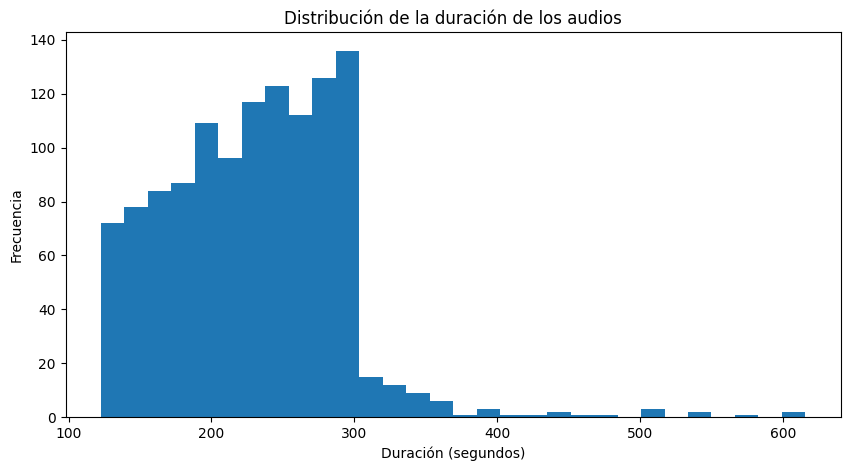

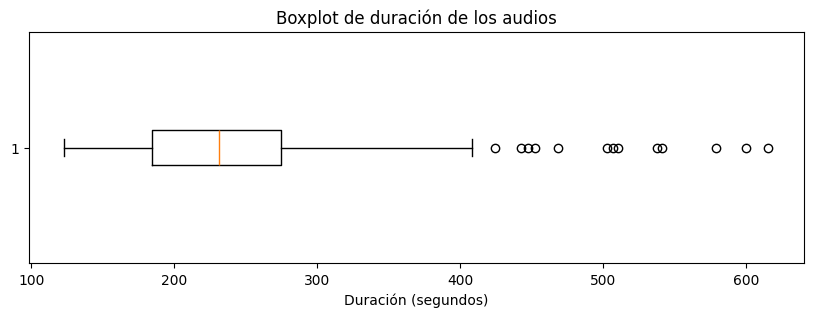


Primeros audios detectados como outliers por duración:


,source_dataset,audio_hash,duration_seconds,duration_outlier
89,raw,6913676400aaf006,452.12,True
130,raw,111150a6defeae8b,600.10,True
291,raw_bajas,8c0936e6ecced070,615.65,True
301,raw_bajas,e01ce95a57853035,510.32,True
316,raw_bajas,7dbb27148000f54f,447.64,True
451,raw_bajas,b681565a32688c8a,537.49,True
565,raw_bajas,0aa7ccdd32a942ad,541.52,True
583,raw_bajas,e2d930cf63d0b5e1,579.12,True
658,raw_bajas,6d14bb015de6c990,442.26,True
674,raw_bajas,c0d429745ec994b5,506.71,True


In [9]:
# =========================
# ANÁLISIS DE DURACIÓN Y DETECCIÓN DE OUTLIERS
# =========================

# Estadísticos básicos
duration_stats = df_audio_inventory["duration_seconds"].describe()
print("Resumen estadístico de la duración de los audios:\n")
print(duration_stats)

# Cálculo de outliers por IQR
q1 = df_audio_inventory["duration_seconds"].quantile(0.25)
q3 = df_audio_inventory["duration_seconds"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_audio_inventory["duration_outlier"] = (
    (df_audio_inventory["duration_seconds"] < lower_bound) |
    (df_audio_inventory["duration_seconds"] > upper_bound)
)

n_outliers = df_audio_inventory["duration_outlier"].sum()

print("\nDetección de outliers por duración:")
print(f"Límite inferior: {lower_bound:.2f} segundos")
print(f"Límite superior: {upper_bound:.2f} segundos")
print(f"Cantidad de audios atípicos: {n_outliers}")

# Histograma de duración
plt.figure(figsize=(10, 5))
plt.hist(df_audio_inventory["duration_seconds"], bins=30)
plt.xlabel("Duración (segundos)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la duración de los audios")
plt.show()

# Boxplot de duración
plt.figure(figsize=(10, 3))
plt.boxplot(df_audio_inventory["duration_seconds"], vert=False)
plt.xlabel("Duración (segundos)")
plt.title("Boxplot de duración de los audios")
plt.show()

# Tabla de audios atípicos, usando identificadores anonimizados para visualización
public_outlier_cols = [
    "source_dataset",
    "audio_hash",
    "duration_seconds",
    "duration_outlier",
]

df_duration_outliers = df_audio_inventory[df_audio_inventory["duration_outlier"]].copy()

print("\nPrimeros audios detectados como outliers por duración:")
df_duration_outliers[public_outlier_cols].head(20)



In [10]:
df_audio_inventory.to_csv(AUDIO_INVENTORY_PRIVATE_CSV, index=False)
print(f"Inventario privado actualizado guardado en: {AUDIO_INVENTORY_PRIVATE_CSV}")

Inventario privado actualizado guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/eda/audio_inventory_private.csv


La distribución de duración de los audios mostró un comportamiento mayoritariamente homogéneo, con únicamente dos valores atípicos detectados mediante el criterio del rango intercuartílico. Ambos corresponden a audios de duración considerablemente superior al resto del conjunto, por lo que se marcaron para revisión específica en fases posteriores del análisis. En términos generales, este resultado sugiere una buena consistencia estructural del dataset en cuanto a duración.

## Análisis de silencio en los audios

Una vez verificada la consistencia básica de la duración de los audios, el siguiente paso del análisis exploratorio consiste en estimar la proporción de silencio presente en cada archivo.

En este contexto, el silencio se entiende como la parte del audio en la que no existe actividad de voz suficientemente significativa. Esta métrica es relevante porque un porcentaje elevado de silencio puede afectar la calidad de la diarización, ya que introduce segmentos sin contenido útil para la separación e identificación de hablantes.

Para este análisis se calcula, por cada audio, la proporción de tiempo no silencioso y la proporción de silencio respecto a la duración total. La detección se realiza sobre la señal de audio a partir de un umbral de energía relativo, expresado mediante el parámetro `top_db`, que permite distinguir regiones activas frente a regiones silenciosas.

El objetivo de esta fase no es eliminar todavía audios ni aplicar limpieza, sino caracterizar el dataset y detectar archivos potencialmente problemáticos para fases posteriores de preprocesado y diarización.

## Selección del threshold para detección de silencio

Con el fin de evaluar la sensibilidad de la métrica de silencio frente al parámetro `top_db`, se compararon distintos valores de threshold. A partir de dicha comparación, se observó que los valores más bajos producían estimaciones excesivamente restrictivas, mientras que los valores más altos tendían a ser demasiado permisivos.

La tabla resumen de esta comparación se conserva como respaldo metodológico del análisis.

In [11]:
# ============================================================
# TABLA RESUMEN DE THRESHOLDS DE SILENCIO
# ============================================================

SILENCE_THRESHOLD_SUMMARY_CSV = EDA_DIR / "silence_threshold_summary.csv"

thresholds = [10, 15, 20, 25, 30, 35, 40, 45, 50]

if SILENCE_THRESHOLD_SUMMARY_CSV.exists():
    print("Cargando tabla de thresholds existente:")
    print(SILENCE_THRESHOLD_SUMMARY_CSV)
    df_silence_threshold_summary = pd.read_csv(SILENCE_THRESHOLD_SUMMARY_CSV, index_col=0)

else:
    print("No existe silence_threshold_summary.csv. Se calculará desde los audios del inventario.")
    print("Esto puede tardar porque descarga los audios y calcula silencio para varios valores de top_db.")

    threshold_rows = []
    total_audios = len(df_audio_inventory)

    for i, row in df_audio_inventory.iterrows():
        source_dataset = row["source_dataset"]
        audio_id = row["audio_id"]
        audio_name = row["audio_name"]
        gcs_uri = row["gcs_uri"]

        clear_output(wait=True)
        print(f"Calculando thresholds {i + 1}/{total_audios}: {source_dataset} | {audio_name}")

        try:
            bucket_name, blob_path = split_gcs_uri(gcs_uri)
            blob = gcs_client.bucket(bucket_name).blob(blob_path)
            audio_bytes = blob.download_as_bytes()

            y, sr = sf.read(io.BytesIO(audio_bytes))

            if y.ndim > 1:
                y = np.mean(y, axis=1)

            total_duration_seconds = len(y) / sr if sr else 0.0

            row_result = {
                "source_dataset": source_dataset,
                "audio_id": audio_id,
                "audio_name": audio_name,
                "duration_seconds": total_duration_seconds,
            }

            for top_db in thresholds:
                nonsilent_intervals = librosa.effects.split(y, top_db=top_db)
                nonsilent_samples = sum(end - start for start, end in nonsilent_intervals)
                nonsilent_duration_seconds = nonsilent_samples / sr if sr else 0.0

                silence_duration_seconds = total_duration_seconds - nonsilent_duration_seconds
                silence_ratio = (
                    silence_duration_seconds / total_duration_seconds
                    if total_duration_seconds > 0 else np.nan
                )

                row_result[f"silence_ratio_top_db_{top_db}"] = silence_ratio

            threshold_rows.append(row_result)

        except Exception as e:
            threshold_rows.append({
                "source_dataset": source_dataset,
                "audio_id": audio_id,
                "audio_name": audio_name,
                "duration_seconds": np.nan,
                "error": str(e),
            })

    df_threshold_detail = pd.DataFrame(threshold_rows)

    summary_rows = []

    for top_db in thresholds:
        col = f"silence_ratio_top_db_{top_db}"

        summary_rows.append({
            "top_db": top_db,
            "mean_silence_ratio": df_threshold_detail[col].mean(),
            "median_silence_ratio": df_threshold_detail[col].median(),
            "std_silence_ratio": df_threshold_detail[col].std(),
            "min_silence_ratio": df_threshold_detail[col].min(),
            "max_silence_ratio": df_threshold_detail[col].max(),
            "audios_silence_gt_60": int((df_threshold_detail[col] > 0.60).sum()),
        })

    df_silence_threshold_summary = pd.DataFrame(summary_rows).set_index("top_db")

    # Guardar detalle y resumen
    df_threshold_detail.to_csv(EDA_DIR / "silence_threshold_detail.csv", index=False)
    df_silence_threshold_summary.to_csv(SILENCE_THRESHOLD_SUMMARY_CSV)

    clear_output(wait=True)
    print("Tabla de thresholds calculada y guardada correctamente.")
    print("Resumen:", SILENCE_THRESHOLD_SUMMARY_CSV)
    print("Detalle:", EDA_DIR / "silence_threshold_detail.csv")

df_silence_threshold_summary

Tabla de thresholds calculada y guardada correctamente.
Resumen: /home/jupyter/TFM_ProcesadoDeAudios/data/eda/silence_threshold_summary.csv
Detalle: /home/jupyter/TFM_ProcesadoDeAudios/data/eda/silence_threshold_detail.csv


,mean_silence_ratio,median_silence_ratio,std_silence_ratio,min_silence_ratio,max_silence_ratio,audios_silence_gt_60
top_db,,,,,,
10,0.732528,0.744762,0.135802,0.270625,0.998161,998
15,0.526927,0.514244,0.167478,0.144877,0.990287,397
20,0.414895,0.383797,0.166653,0.092260,0.983896,199
25,0.361714,0.327459,0.164964,0.058613,0.967537,126
30,0.328715,0.297048,0.162853,0.000000,0.946577,85
35,0.297326,0.267846,0.158997,0.000000,0.923572,59
40,0.263310,0.232162,0.156390,0.000000,0.899545,43
45,0.227261,0.194139,0.152822,0.000000,0.870832,28
50,0.189585,0.147862,0.147925,0.000000,0.866778,19


A partir de la comparación de thresholds sobre el conjunto ampliado de 1200 audios, se mantiene `top_db = 30` como valor de trabajo. Este umbral presenta un comportamiento intermedio entre valores demasiado restrictivos, que clasifican una proporción excesiva del dataset como silencio, y valores demasiado permisivos, que reducen significativamente la detección de segmentos silenciosos. Con `top_db = 30`, la proporción media de silencio se sitúa alrededor del 33% y se identifican 85 audios con más de 60% de silencio, lo que permite conservar sensibilidad frente a casos problemáticos sin sobredimensionar artificialmente el fenómeno.

In [12]:
# PARÁMETROS DE DETECCIÓN DE SILENCIO

SILENCE_TOP_DB = 30

print(f"Parámetro de silencio configurado correctamente. SILENCE_TOP_DB = {SILENCE_TOP_DB}")

Parámetro de silencio configurado correctamente. SILENCE_TOP_DB = 30


In [13]:
# =========================
# CÁLCULO DE PROPORCIÓN DE SILENCIO
# =========================

silence_rows = []
errores_silencio = []

total_audios = len(df_audio_inventory)

for i, row in df_audio_inventory.iterrows():
    source_dataset = row["source_dataset"]
    audio_id = row["audio_id"]
    audio_name = row["audio_name"]
    gcs_uri = row["gcs_uri"]

    clear_output(wait=True)
    print(f"Calculando silencio {i + 1}/{total_audios}: {source_dataset} | {audio_name}")

    try:
        bucket_name, blob_path = split_gcs_uri(gcs_uri)
        blob = gcs_client.bucket(bucket_name).blob(blob_path)
        audio_bytes = blob.download_as_bytes()

        y, sr = sf.read(io.BytesIO(audio_bytes))

        if y.ndim > 1:
            y = np.mean(y, axis=1)

        total_duration_seconds = len(y) / sr if sr else 0.0

        nonsilent_intervals = librosa.effects.split(y, top_db=SILENCE_TOP_DB)

        nonsilent_samples = sum(end - start for start, end in nonsilent_intervals)
        nonsilent_duration_seconds = nonsilent_samples / sr if sr else 0.0

        silence_duration_seconds = total_duration_seconds - nonsilent_duration_seconds
        silence_ratio = (
            silence_duration_seconds / total_duration_seconds
            if total_duration_seconds > 0 else np.nan
        )
        nonsilent_ratio = (
            nonsilent_duration_seconds / total_duration_seconds
            if total_duration_seconds > 0 else np.nan
        )

        silence_rows.append({
            "source_dataset": source_dataset,
            "audio_id": audio_id,
            "silence_duration_seconds": silence_duration_seconds,
            "silence_ratio": silence_ratio,
            "nonsilent_duration_seconds": nonsilent_duration_seconds,
            "nonsilent_ratio": nonsilent_ratio
        })

    except Exception as e:
        errores_silencio.append({
            "source_dataset": source_dataset,
            "audio_id": audio_id,
            "audio_name": audio_name,
            "gcs_uri": gcs_uri,
            "error": str(e)
        })

clear_output(wait=True)
print("Cálculo de silencio finalizado.")
print(f"Audios procesados correctamente: {len(silence_rows)}")
print(f"Errores detectados: {len(errores_silencio)}")

df_silence = pd.DataFrame(silence_rows)
df_errores_silencio = pd.DataFrame(errores_silencio)

Cálculo de silencio finalizado.
Audios procesados correctamente: 1200
Errores detectados: 0


In [14]:
# =========================
# INTEGRACIÓN DE MÉTRICAS DE SILENCIO AL INVENTARIO
# =========================

# El merge debe hacerse con doble llave para no perder la columna source_dataset
# ni mezclar registros de raw y raw_bajas con el mismo audio_id.
df_audio_inventory = df_audio_inventory.merge(
    df_silence,
    on=["source_dataset", "audio_id"],
    how="left"
)

print("Métricas de silencio integradas correctamente al inventario.")
print(f"Dimensiones del inventario maestro: {df_audio_inventory.shape}")

df_audio_inventory[
    [
        "source_dataset",
        "audio_hash",
        "customer_hash",
        "duration_seconds",
        "silence_ratio",
        "nonsilent_ratio"
    ]
].head()



Métricas de silencio integradas correctamente al inventario.
Dimensiones del inventario maestro: (1200, 25)


,source_dataset,audio_hash,customer_hash,duration_seconds,silence_ratio,nonsilent_ratio
0,raw,59bbb26cd2aa85af,a9caf51c656e2261,180.15,0.165495,0.834505
1,raw,279636e636f34590,73e95b4635bee260,199.74,0.264003,0.735997
2,raw,79b777645a52ce64,65523adc7416146b,151.50,0.181228,0.818772
3,raw,f684b7607e56d8cf,159dd2c11f28eb26,270.29,0.139702,0.860298
4,raw,87b88d68991a6979,87ac862422b770da,187.56,0.187887,0.812113


In [15]:
# =========================
# REVISIÓN BÁSICA DE SILENCIO
# =========================

print("Resumen estadístico de la proporción de silencio:\n")
print(df_audio_inventory["silence_ratio"].describe())

print("\nAudios con mayor proporción de silencio:\n")
df_audio_inventory[
    [
        "source_dataset",
        "audio_hash",
        "duration_seconds",
        "silence_ratio"
    ]
].sort_values(
    by="silence_ratio",
    ascending=False
).head(20)



Resumen estadístico de la proporción de silencio:

count    1200.000000
mean        0.328715
std         0.162853
min         0.000000
25%         0.201087
50%         0.297048
75%         0.435171
max         0.946577
Name: silence_ratio, dtype: float64

Audios con mayor proporción de silencio:



,source_dataset,audio_hash,duration_seconds,silence_ratio
107,raw,NaN,250.38,0.946577
291,raw_bajas,8c0936e6ecced070,615.65,0.882739
822,raw_bajas,4ff94c56ac40b873,343.33,0.810794
867,raw_bajas,aa24db55e72436d6,287.84,0.794108
1088,raw_bajas,03a87cb052b65438,220.16,0.792733
409,raw_bajas,cd2f4267fbca010b,245.20,0.776052
981,raw_bajas,9d968664334bca6b,194.53,0.775294
573,raw_bajas,76625f0287ea9fcf,298.20,0.770999
293,raw_bajas,8cc172c6d9f1e3e0,250.18,0.767463
517,raw_bajas,e94f3226a3eba779,182.47,0.756234


## Interpretación inicial de la proporción de silencio

El análisis de silencio sobre el corpus ampliado de 1200 audios muestra que, en promedio, aproximadamente el 32,9% de la duración total corresponde a segmentos sin actividad de voz detectada. La mediana se sitúa en torno al 29,7%, por lo que la presencia de silencio no se concentra únicamente en unos pocos casos extremos, sino que forma parte del comportamiento general del conjunto.

También se identifican audios con proporciones de silencio especialmente elevadas, incluyendo varios casos por encima del 70% y un valor máximo cercano al 95%. Estos archivos se consideran candidatos a revisión posterior, ya que una baja densidad de voz útil puede afectar la estabilidad de etapas posteriores como la diarización, la selección de segmentos válidos y la extracción de huellas de voz.

En esta fase no se excluyen audios automáticamente por su proporción de silencio. La métrica se incorpora al inventario maestro como variable de control para cruzarla posteriormente con los resultados de limpieza, solapamiento, diarización y validez de segmentos.

## Visualización de la proporción de silencio

Con el objetivo de comprender mejor la distribución de la proporción de silencio en el conjunto de datos, se utilizan dos representaciones gráficas complementarias.

En primer lugar, se emplea un histograma para observar la distribución global de la proporción de silencio y detectar posibles concentraciones o dispersión en los valores.

En segundo lugar, se analiza la relación entre la duración de los audios y la proporción de silencio mediante un gráfico de dispersión. Esta visualización permite identificar posibles patrones estructurales, como la tendencia de audios más largos a contener mayores periodos de silencio, así como detectar casos atípicos.

Estas representaciones facilitan la interpretación del comportamiento del dataset y sirven de base para decisiones posteriores en el preprocesado del audio.

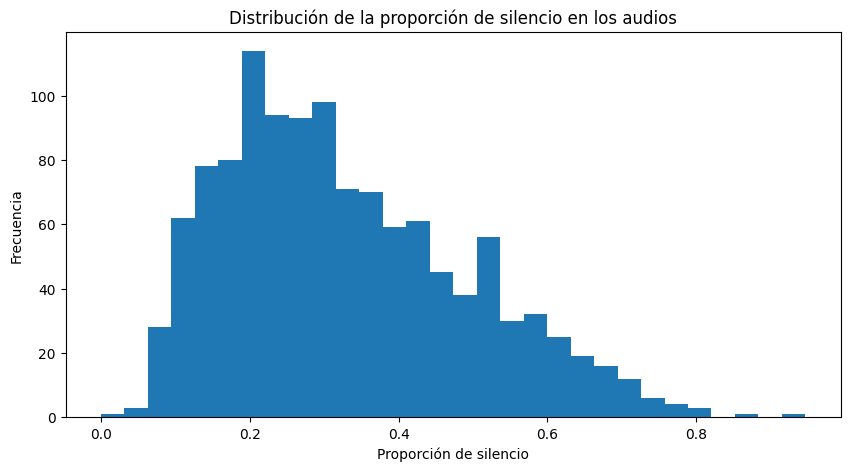

In [16]:
# =========================
# DISTRIBUCIÓN DE LA PROPORCIÓN DE SILENCIO
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_audio_inventory["silence_ratio"], bins=30)
plt.xlabel("Proporción de silencio")
plt.ylabel("Frecuencia")
plt.title("Distribución de la proporción de silencio en los audios")
plt.show()

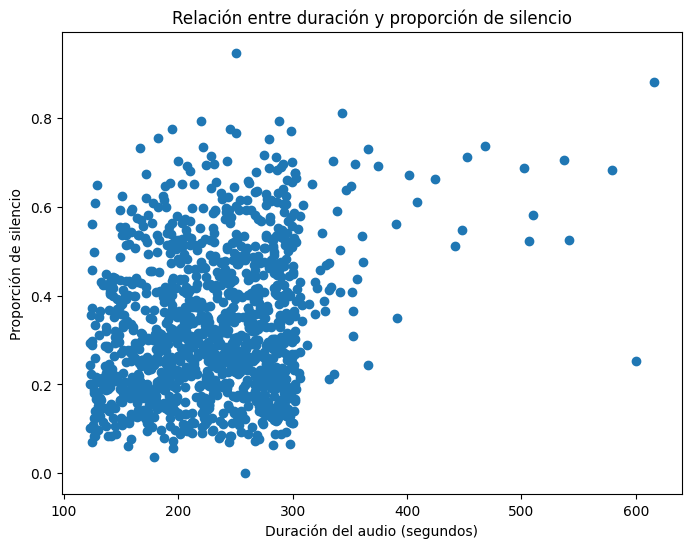

In [17]:
# =========================
# RELACIÓN ENTRE DURACIÓN Y PROPORCIÓN DE SILENCIO
# =========================

plt.figure(figsize=(8, 6))
plt.scatter(
    df_audio_inventory["duration_seconds"],
    df_audio_inventory["silence_ratio"]
)

plt.xlabel("Duración del audio (segundos)")
plt.ylabel("Proporción de silencio")
plt.title("Relación entre duración y proporción de silencio")
plt.show()

# FASE 2. Limpieza y preprocesado inicial de audios

Una vez completado el análisis exploratorio de datos y consolidada esta información en un inventario maestro enriquecido con metadata externa, se inicia la fase de limpieza y preprocesado inicial de los audios.

El objetivo de esta etapa es estandarizar los archivos de audio y reducir la presencia de segmentos no informativos que puedan afectar análisis posteriores. En particular, se busca transformar todos los audios a un formato homogéneo, convertirlos a mono, remuestrearlos a 16 kHz y aplicar un recorte inicial de silencios excesivos, preservando en lo posible la estructura conversacional del archivo.

Esta fase permite generar una primera versión limpia de los audios, así como una tabla de resultados que documenta el efecto del preprocesado sobre cada archivo.

In [18]:
# =========================
# FUNCIONES BASE DE LIMPIEZA
# =========================

def load_audio_standard_from_gcs(gcs_uri, target_sr=16000):
    """
    Descarga un audio desde GCS, lo carga, lo convierte a mono y lo remuestrea a target_sr.
    """
    bucket_name, blob_path = split_gcs_uri(gcs_uri)
    blob = gcs_client.bucket(bucket_name).blob(blob_path)
    audio_bytes = blob.download_as_bytes()

    y, sr = sf.read(io.BytesIO(audio_bytes), always_2d=False)

    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = np.mean(y, axis=1)

    y = y.astype(np.float32)

    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    return y, sr, audio_bytes


def plot_waveform(y, sr, title="Waveform"):
    plt.figure(figsize=(14, 4))
    plt.plot(np.arange(len(y)) / sr, y)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


def basic_audio_stats(y, sr):
    duration_sec = len(y) / sr if sr > 0 else 0.0
    max_amp = float(np.max(np.abs(y))) if len(y) > 0 else 0.0
    rms = float(np.sqrt(np.mean(y ** 2))) if len(y) > 0 else 0.0

    return {
        "duration_sec": duration_sec,
        "max_amplitude": max_amp,
        "rms_energy": rms
    }

In [19]:
# FUNCIÓN PRINCIPAL DE LIMPIEZA

def clean_audio_hybrid(
    y,
    sr,
    top_db=30,
    min_silence_len_sec=0.30,
    max_internal_silence_sec=0.75,
):
    """
    Limpieza híbrida inicial:
    1. elimina silencio inicial y final
    2. conserva voz
    3. recorta silencios internos excesivos a un máximo configurable

    Parámetros
    ----------
    y : np.ndarray
        Señal mono.
    sr : int
        Sample rate.
    top_db : int
        Umbral de silencio para librosa.effects.split.
    min_silence_len_sec : float
        Silencios muy pequeños se dejan tal cual como pausas naturales.
    max_internal_silence_sec : float
        Si un silencio interno supera este valor, se recorta a este máximo.

    Devuelve
    --------
    y_clean : np.ndarray
        Audio limpio.
    cleaning_info : dict
        Métricas y decisiones del proceso.
    """
    original_stats = basic_audio_stats(y, sr)

    nonsilent_intervals = librosa.effects.split(y, top_db=top_db)

    if len(nonsilent_intervals) == 0:
        cleaning_info = {
            "status": "empty_after_split",
            "top_db": top_db,
            "original_duration_sec": original_stats["duration_sec"],
            "clean_duration_sec": 0.0,
            "removed_duration_sec": original_stats["duration_sec"],
            "removed_ratio": 1.0 if original_stats["duration_sec"] > 0 else np.nan,
            "n_nonsilent_intervals": 0,
            "trim_applied": False,
            "internal_silence_compression_applied": False,
            "max_internal_silence_sec": max_internal_silence_sec,
        }
        return np.array([], dtype=np.float32), cleaning_info

    chunks = []
    internal_silence_compression_applied = False

    for idx, (start, end) in enumerate(nonsilent_intervals):
        chunks.append(y[start:end])

        if idx < len(nonsilent_intervals) - 1:
            next_start = nonsilent_intervals[idx + 1][0]
            gap_samples = next_start - end
            gap_sec = gap_samples / sr

            if gap_sec <= min_silence_len_sec:
                gap_to_keep_samples = gap_samples
            else:
                gap_to_keep_samples = int(min(gap_sec, max_internal_silence_sec) * sr)
                if gap_sec > max_internal_silence_sec:
                    internal_silence_compression_applied = True

            if gap_to_keep_samples > 0:
                chunks.append(np.zeros(gap_to_keep_samples, dtype=y.dtype))

    y_clean = np.concatenate(chunks) if len(chunks) > 0 else np.array([], dtype=np.float32)
    clean_stats = basic_audio_stats(y_clean, sr)

    removed_duration_sec = original_stats["duration_sec"] - clean_stats["duration_sec"]
    removed_ratio = (
        removed_duration_sec / original_stats["duration_sec"]
        if original_stats["duration_sec"] > 0 else np.nan
    )

    cleaning_info = {
        "status": "ok",
        "top_db": top_db,
        "original_duration_sec": original_stats["duration_sec"],
        "clean_duration_sec": clean_stats["duration_sec"],
        "removed_duration_sec": removed_duration_sec,
        "removed_ratio": removed_ratio,
        "n_nonsilent_intervals": len(nonsilent_intervals),
        "trim_applied": True,
        "internal_silence_compression_applied": internal_silence_compression_applied,
        "max_internal_silence_sec": max_internal_silence_sec,
        "original_max_amplitude": original_stats["max_amplitude"],
        "clean_max_amplitude": clean_stats["max_amplitude"],
        "original_rms_energy": original_stats["rms_energy"],
        "clean_rms_energy": clean_stats["rms_energy"],
    }

    return y_clean, cleaning_info

In [20]:
# =========================
# FUNCIÓN DE PROCESAMIENTO DE UN SOLO AUDIO
# =========================

def process_one_audio(
    row,
    clean_gcs_prefix,
    top_db=30,
    target_sr=16000,
    min_silence_len_sec=0.30,
    max_internal_silence_sec=0.75,
    min_valid_duration_sec=10.0,
    max_removed_ratio=0.90,
):
    """
    Procesa un audio del inventario maestro, aplica limpieza y sube el resultado limpio a GCS.
    """
    source_dataset = row["source_dataset"]
    audio_id = row["audio_id"]
    audio_name = row["audio_name"]
    gcs_uri = row["gcs_uri"]

    y, sr, _ = load_audio_standard_from_gcs(gcs_uri, target_sr=target_sr)

    y_clean, cleaning_info = clean_audio_hybrid(
        y=y,
        sr=sr,
        top_db=top_db,
        min_silence_len_sec=min_silence_len_sec,
        max_internal_silence_sec=max_internal_silence_sec,
    )

    clean_filename = f"{source_dataset}_{audio_id}_clean.wav"

    clean_bucket_name, clean_prefix = split_gcs_uri(clean_gcs_prefix)
    clean_blob_path = f"{clean_prefix}{clean_filename}"
    clean_gcs_uri = f"gs://{clean_bucket_name}/{clean_blob_path}"

    valid_audio = (
        cleaning_info["status"] == "ok"
        and len(y_clean) > 0
        and cleaning_info["clean_duration_sec"] >= min_valid_duration_sec
        and cleaning_info["removed_ratio"] <= max_removed_ratio
    )

    if valid_audio:
        audio_buffer = io.BytesIO()
        sf.write(audio_buffer, y_clean, sr, format="WAV")
        audio_buffer.seek(0)

        clean_blob = gcs_client.bucket(clean_bucket_name).blob(clean_blob_path)
        clean_blob.upload_from_file(audio_buffer, content_type="audio/wav")

    result = {
        "source_dataset": source_dataset,
        "audio_id": audio_id,
        "audio_name": audio_name,
        "gcs_uri": gcs_uri,
        "clean_filename": clean_filename if valid_audio else None,
        "clean_gcs_uri": clean_gcs_uri if valid_audio else None,
        "valid_audio": valid_audio,
        "target_sr": target_sr,
        "min_valid_duration_sec": min_valid_duration_sec,
        "max_removed_ratio": max_removed_ratio,
        **cleaning_info,
    }

    return result



In [21]:
# PARÁMETROS DE LIMPIEZA

CLEAN_TOP_DB = SILENCE_TOP_DB
CLEAN_TARGET_SR = 16000
MIN_SILENCE_LEN_SEC = 0.30
MAX_INTERNAL_SILENCE_SEC = 0.75

MIN_VALID_DURATION_SEC = 10.0
MAX_REMOVED_RATIO = 0.90

## Criterios de validez tras la limpieza

Una vez aplicado el preprocesado, cada audio se clasifica como válido o no válido para etapas posteriores. En esta primera versión, un audio se considera válido cuando el proceso de limpieza finaliza correctamente, el archivo resultante no queda vacío, la duración limpia supera un mínimo razonable y la proporción eliminada no excede un umbral máximo.

Este criterio busca evitar que audios excesivamente recortados, vacíos o demasiado breves pasen a fases posteriores del pipeline.

In [ ]:
# =========================
# LIMPIEZA POR LOTE DE TODOS LOS AUDIOS
# =========================

cleaning_results = []
cleaning_errors = []

total_audios = len(df_audio_inventory)

for i, (_, row) in enumerate(df_audio_inventory.iterrows(), start=1):
    source_dataset = row["source_dataset"]
    audio_name = row["audio_name"]

    clear_output(wait=True)
    print(f"Limpieza de audios {i}/{total_audios}: {source_dataset} | {audio_name}")

    try:
        result = process_one_audio(
            row=row,
            clean_gcs_prefix=GCS_UNAV_CLEAN_AUDIO_PREFIX,
            top_db=CLEAN_TOP_DB,
            target_sr=CLEAN_TARGET_SR,
            min_silence_len_sec=MIN_SILENCE_LEN_SEC,
            max_internal_silence_sec=MAX_INTERNAL_SILENCE_SEC,
            min_valid_duration_sec=MIN_VALID_DURATION_SEC,
            max_removed_ratio=MAX_REMOVED_RATIO,
        )
        cleaning_results.append(result)

    except Exception as e:
        cleaning_errors.append({
            "source_dataset": row.get("source_dataset", None),
            "audio_id": row.get("audio_id", None),
            "audio_name": row.get("audio_name", None),
            "gcs_uri": row.get("gcs_uri", None),
            "valid_audio": False,
            "status": "error",
            "error": str(e),
        })

clear_output(wait=True)
print("Limpieza por lote finalizada.")
print(f"Audios procesados correctamente: {len(cleaning_results)}")
print(f"Errores detectados: {len(cleaning_errors)}")

Limpieza por lote finalizada.
Audios procesados correctamente: 1200
Errores detectados: 0


In [ ]:
# =========================
# CONSTRUCCIÓN Y GUARDADO DE RESULTADOS DE LIMPIEZA
# =========================

df_cleaning_results = pd.DataFrame(cleaning_results)
df_cleaning_errors = pd.DataFrame(cleaning_errors)

if not df_cleaning_errors.empty:
    for col in df_cleaning_results.columns:
        if col not in df_cleaning_errors.columns:
            df_cleaning_errors[col] = np.nan

    df_cleaning_results = pd.concat(
        [df_cleaning_results, df_cleaning_errors[df_cleaning_results.columns]],
        ignore_index=True
    )

# Guardado local privado
df_cleaning_results.to_csv(CLEANING_RESULTS_PRIVATE_CSV, index=False)

# Copia privada en GCS para trazabilidad del pipeline
cleaning_results_blob = bucket.blob(
    f"{UNAV_CSV_PREFIX}audio_cleaning_results_private.csv"
)
cleaning_results_blob.upload_from_filename(str(CLEANING_RESULTS_PRIVATE_CSV))

print(f"Resultados completos de limpieza guardados localmente en: {CLEANING_RESULTS_PRIVATE_CSV}")
print(f"Resultados completos de limpieza subidos a: gs://{GCS_BUCKET_NAME}/{UNAV_CSV_PREFIX}audio_cleaning_results_private.csv")

# Vista segura sin IDs reales
df_cleaning_results[
    [
        "source_dataset",
        "valid_audio",
        "status",
        "original_duration_sec",
        "clean_duration_sec",
        "removed_ratio",
        "clean_gcs_uri"
    ]
].head()



Resultados completos de limpieza guardados localmente en: /home/jupyter/TFM_ProcesadoDeAudios/data/clean_results/audio_cleaning_results_private.csv
Resultados completos de limpieza subidos a: gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_cleaning_results_private.csv


,source_dataset,valid_audio,status,original_duration_sec,clean_duration_sec,removed_ratio,clean_gcs_uri
0,raw,True,ok,180.15,171.378,0.048693,gs://catedras_audio_detection/pipelineA/proces...
1,raw,True,ok,199.74,175.562,0.121047,gs://catedras_audio_detection/pipelineA/proces...
2,raw,True,ok,151.50,143.380,0.053597,gs://catedras_audio_detection/pipelineA/proces...
3,raw,True,ok,270.29,265.398,0.018099,gs://catedras_audio_detection/pipelineA/proces...
4,raw,True,ok,187.56,172.388,0.080891,gs://catedras_audio_detection/pipelineA/proces...


In [ ]:
# =========================
# GENERACIÓN DE AUDIOS VÁLIDOS PARA ETAPAS POSTERIORES
# =========================

df_valid_audio = df_cleaning_results[df_cleaning_results["valid_audio"] == True].copy()

# Guardado local privado
df_valid_audio.to_csv(VALID_AUDIO_PRIVATE_CSV, index=False)

# Copia privada en GCS para trazabilidad del pipeline
valid_audio_blob = bucket.blob(
    f"{UNAV_CSV_PREFIX}audio_valid_for_diarization_private.csv"
)
valid_audio_blob.upload_from_filename(str(VALID_AUDIO_PRIVATE_CSV))

print(f"Audios válidos guardados localmente en: {VALID_AUDIO_PRIVATE_CSV}")
print(f"Audios válidos subidos a: gs://{GCS_BUCKET_NAME}/{UNAV_CSV_PREFIX}audio_valid_for_diarization_private.csv")
print(f"Cantidad de audios válidos: {len(df_valid_audio)}")
print(f"Cantidad de audios no válidos: {(df_cleaning_results['valid_audio'] == False).sum()}")

# Vista segura sin IDs reales
df_valid_audio[
    [
        "source_dataset",
        "valid_audio",
        "status",
        "clean_filename",
        "clean_gcs_uri",
        "clean_duration_sec",
        "removed_ratio"
    ]
].head()



Audios válidos guardados localmente en: /home/jupyter/TFM_ProcesadoDeAudios/data/clean_results/audio_valid_for_diarization_private.csv
Audios válidos subidos a: gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_valid_for_diarization_private.csv
Cantidad de audios válidos: 1200
Cantidad de audios no válidos: 0


,source_dataset,valid_audio,status,clean_filename,clean_gcs_uri,clean_duration_sec,removed_ratio
0,raw,True,ok,raw_9154117451310006851_clean.wav,gs://catedras_audio_detection/pipelineA/proces...,171.378,0.048693
1,raw,True,ok,raw_9154117551220006851_clean.wav,gs://catedras_audio_detection/pipelineA/proces...,175.562,0.121047
2,raw,True,ok,raw_9154127337680006851_clean.wav,gs://catedras_audio_detection/pipelineA/proces...,143.380,0.053597
3,raw,True,ok,raw_9154142438160016851_clean.wav,gs://catedras_audio_detection/pipelineA/proces...,265.398,0.018099
4,raw,True,ok,raw_9154152155960016851_clean.wav,gs://catedras_audio_detection/pipelineA/proces...,172.388,0.080891


In [ ]:
# =========================
# INTEGRACIÓN DE RESULTADOS DE LIMPIEZA AL INVENTARIO MAESTRO
# =========================

cleaning_cols = [
    "source_dataset",
    "audio_id",
    "valid_audio",
    "status",
    "original_duration_sec",
    "clean_duration_sec",
    "removed_duration_sec",
    "removed_ratio",
    "n_nonsilent_intervals",
    "trim_applied",
    "internal_silence_compression_applied",
    "clean_filename",
    "clean_gcs_uri",
]

df_audio_inventory = df_audio_inventory.merge(
    df_cleaning_results[cleaning_cols],
    on=["source_dataset", "audio_id"],
    how="left"
)

print("Resultados de limpieza integrados correctamente al inventario maestro.")
print(f"Dimensiones del inventario maestro: {df_audio_inventory.shape}")

df_audio_inventory[
    [
        "source_dataset",
        "audio_hash",
        "customer_hash",
        "valid_audio",
        "status",
        "clean_duration_sec",
        "removed_ratio",
        "clean_gcs_uri",
    ]
].head()



Resultados de limpieza integrados correctamente al inventario maestro.
Dimensiones del inventario maestro: (1200, 36)


,source_dataset,audio_hash,customer_hash,valid_audio,status,clean_duration_sec,removed_ratio,clean_gcs_uri
0,raw,59bbb26cd2aa85af,a9caf51c656e2261,True,ok,171.378,0.048693,gs://catedras_audio_detection/pipelineA/proces...
1,raw,279636e636f34590,73e95b4635bee260,True,ok,175.562,0.121047,gs://catedras_audio_detection/pipelineA/proces...
2,raw,79b777645a52ce64,65523adc7416146b,True,ok,143.380,0.053597,gs://catedras_audio_detection/pipelineA/proces...
3,raw,f684b7607e56d8cf,159dd2c11f28eb26,True,ok,265.398,0.018099,gs://catedras_audio_detection/pipelineA/proces...
4,raw,87b88d68991a6979,87ac862422b770da,True,ok,172.388,0.080891,gs://catedras_audio_detection/pipelineA/proces...


## Visualización del efecto de la limpieza sobre los audios

Una vez aplicado el proceso de limpieza y preprocesado, se analizan sus efectos sobre la duración de los audios y sobre la proporción de señal eliminada.

Estas visualizaciones permiten verificar si la limpieza se comporta de forma razonable sobre el conjunto de datos, identificar posibles casos extremos y evaluar si el procedimiento está conservando la mayor parte del contenido útil de cada archivo.

En particular, se comparan las duraciones originales y limpias, se estudia la distribución de la proporción eliminada y se observa la relación entre duración original y porcentaje de recorte aplicado.

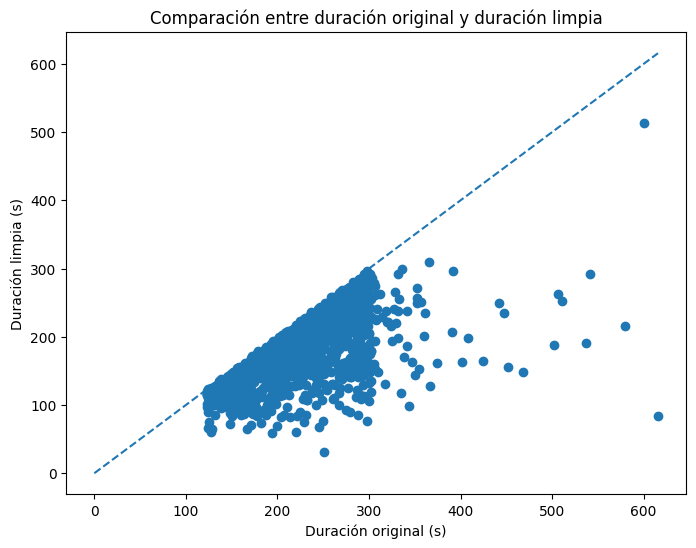

In [ ]:
# =========================
# COMPARACIÓN ENTRE DURACIÓN ORIGINAL Y DURACIÓN LIMPIA
# =========================

df_plot_clean = df_cleaning_results[df_cleaning_results["status"] == "ok"].copy()

plt.figure(figsize=(8, 6))
plt.scatter(
    df_plot_clean["original_duration_sec"],
    df_plot_clean["clean_duration_sec"]
)

max_duration = max(
    df_plot_clean["original_duration_sec"].max(),
    df_plot_clean["clean_duration_sec"].max()
)

plt.plot([0, max_duration], [0, max_duration], linestyle="--")
plt.xlabel("Duración original (s)")
plt.ylabel("Duración limpia (s)")
plt.title("Comparación entre duración original y duración limpia")
plt.show()

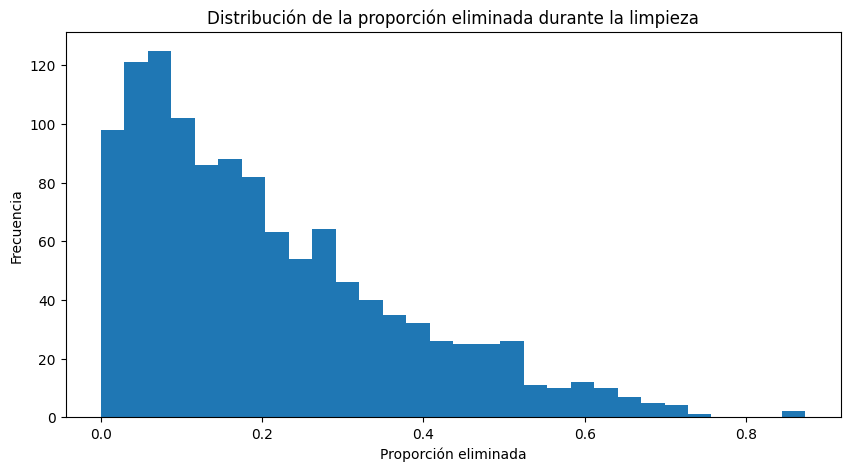

In [ ]:
# =========================
# DISTRIBUCIÓN DE LA PROPORCIÓN ELIMINADA
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_plot_clean["removed_ratio"], bins=30)
plt.xlabel("Proporción eliminada")
plt.ylabel("Frecuencia")
plt.title("Distribución de la proporción eliminada durante la limpieza")
plt.show()

In [ ]:
# =========================
# RESUMEN ESTADÍSTICO DE LA LIMPIEZA
# =========================

df_plot_clean[[
    "original_duration_sec",
    "clean_duration_sec",
    "removed_duration_sec",
    "removed_ratio"
]].describe()

,original_duration_sec,clean_duration_sec,removed_duration_sec,removed_ratio
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,230.400150,179.362410,51.037740,0.208629
std,62.468884,52.928104,50.348875,0.163468
min,122.640000,31.582000,0.000000,0.000000
25%,184.375000,140.476000,15.955500,0.074510
50%,231.200000,174.497000,37.834000,0.167887
75%,274.545000,217.354500,69.195500,0.303709
max,615.650000,513.008000,531.738000,0.873864


In [ ]:
# =========================
# DISTRIBUCIÓN DE AUDIOS POR CLIENTE Y AGENTE
# =========================

df_customer_counts = (
    df_audio_inventory
    .dropna(subset=["customer_id"])
    .groupby(["customer_id", "customer_hash"])
    .size()
    .reset_index(name="n_audios")
    .sort_values("n_audios", ascending=False)
)

df_agent_counts = (
    df_audio_inventory
    .dropna(subset=["agent_id"])
    .groupby(["agent_id", "agent_hash"])
    .size()
    .reset_index(name="n_audios")
    .sort_values("n_audios", ascending=False)
)

print("Resumen por cliente:")
print(df_customer_counts["n_audios"].describe())

print("\nResumen por agente:")
print(df_agent_counts["n_audios"].describe())

print("\nTop clientes por número de audios:")
display(df_customer_counts[["customer_hash", "n_audios"]].head(20))

print("\nTop agentes por número de audios:")
display(df_agent_counts[["agent_hash", "n_audios"]].head(20))

Resumen por cliente:
count    1049.000000
mean        1.142993
std         0.556494
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         9.000000
Name: n_audios, dtype: float64

Resumen por agente:
count    474.000000
mean       2.529536
std        2.584752
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max       24.000000
Name: n_audios, dtype: float64

Top clientes por número de audios:


,customer_hash,n_audios
0,41254e90b1648817,9
7,72c341fb27420022,8
85,18a87e74b0870b20,6
41,800b3989edfa41c4,5
65,d43583e5ccac307f,4
69,987968ef04333f13,4
64,608ed12a45fd37a2,4
29,49fd1cf61a61a973,4
66,73e95b4635bee260,4
90,9b3b058b04a46f6b,4



Top agentes por número de audios:


,agent_hash,n_audios
73,1f043ebbae5336e1,24
112,6616fc047cc47e17,15
159,900ae8a37e6cf2ff,14
154,4944e019e9533bb8,13
19,ee3b303a340552ab,12
105,d144a009061ed19e,12
111,30c4ded51c534ca6,12
115,9e6cc6534d8f50ef,11
26,b66dbf3e011c64c2,10
24,3b18a9f79bbf2ce9,10


In [ ]:
# =========================
# CLIENTES CON MÚLTIPLES AUDIOS
# =========================

MIN_AUDIOS_PER_CUSTOMER = 2

df_customers_trainable = df_customer_counts[
    df_customer_counts["n_audios"] >= MIN_AUDIOS_PER_CUSTOMER
].copy()

trainable_customer_ids = set(df_customers_trainable["customer_id"])

df_voiceprint_candidates = df_audio_inventory[
    df_audio_inventory["customer_id"].isin(trainable_customer_ids)
].copy()

print(f"Clientes con al menos {MIN_AUDIOS_PER_CUSTOMER} audios: {len(df_customers_trainable)}")
print(f"Audios candidatos para entrenamiento/evaluación de huella: {len(df_voiceprint_candidates)}")

display(df_customers_trainable[["customer_hash", "n_audios"]].head(20))

Clientes con al menos 2 audios: 104
Audios candidatos para entrenamiento/evaluación de huella: 254


,customer_hash,n_audios
0,41254e90b1648817,9
7,72c341fb27420022,8
85,18a87e74b0870b20,6
41,800b3989edfa41c4,5
65,d43583e5ccac307f,4
69,987968ef04333f13,4
64,608ed12a45fd37a2,4
29,49fd1cf61a61a973,4
66,73e95b4635bee260,4
90,9b3b058b04a46f6b,4


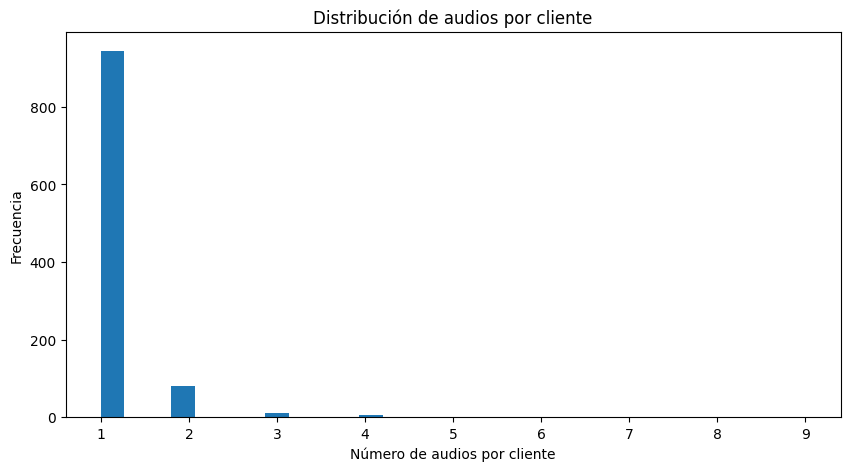

In [ ]:
# =========================
# HISTOGRAMA DE AUDIOS POR CLIENTE
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_customer_counts["n_audios"], bins=30)
plt.xlabel("Número de audios por cliente")
plt.ylabel("Frecuencia")
plt.title("Distribución de audios por cliente")
plt.show()

In [ ]:
# ============================================================
# GUARDADO FINAL NOTEBOOK 00
# Subir TODOS los CSV locales actuales a Google Cloud Storage
# Sobrescribe versiones anteriores con el mismo nombre
# ============================================================

from pathlib import Path
from google.cloud import storage

# ------------------------------------------------------------
# 1. Asegurar cliente, bucket y prefijo de destino
# ------------------------------------------------------------

try:
    gcs_client
except NameError:
    gcs_client = storage.Client()

try:
    bucket
except NameError:
    bucket = gcs_client.bucket(GCS_BUCKET_NAME)

try:
    UNAV_CSV_PREFIX
except NameError:
    # Si solo existe la ruta gs:// completa, la convierte a prefijo interno del bucket
    if "GCS_UNAV_CSV_PREFIX" in globals():
        _, UNAV_CSV_PREFIX = split_gcs_uri(GCS_UNAV_CSV_PREFIX)
    else:
        UNAV_CSV_PREFIX = "pipelineA/procesados_UNAV/csv_outputs/"

# ------------------------------------------------------------
# 2. Carpetas locales del Notebook 00 donde se generan CSVs
# ------------------------------------------------------------

local_csv_dirs = [
    Path(EDA_DIR),
    Path(CLEAN_RESULTS_DIR),
]

# ------------------------------------------------------------
# 3. Buscar todos los CSV locales existentes
# ------------------------------------------------------------

csv_files = []

for local_dir in local_csv_dirs:
    if local_dir.exists():
        csv_files.extend(sorted(local_dir.glob("*.csv")))
    else:
        print(f"No existe carpeta local: {local_dir}")

# Eliminar duplicados por seguridad
csv_files = sorted(set(csv_files))

print("CSV locales encontrados:", len(csv_files))
print("Destino GCS:", f"gs://{GCS_BUCKET_NAME}/{UNAV_CSV_PREFIX}")
print()

# ------------------------------------------------------------
# 4. Subir CSVs a GCS
# ------------------------------------------------------------

if not csv_files:
    print("No se encontraron CSV locales para subir.")

else:
    for csv_path in csv_files:
        blob_name = f"{UNAV_CSV_PREFIX}{csv_path.name}"
        blob = bucket.blob(blob_name)

        # Sobrescribe si ya existe
        blob.upload_from_filename(str(csv_path))

        size_mb = csv_path.stat().st_size / (1024 * 1024)

        print(
            f"Subido: {csv_path.name:55} "
            f"{size_mb:8.2f} MB  ->  gs://{GCS_BUCKET_NAME}/{blob_name}"
        )

print("\nSubida final de CSV del Notebook 00 terminada.")

CSV locales encontrados: 7
Destino GCS: gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/

Subido: audio_cleaning_results.csv                                  0.38 MB  ->  gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_cleaning_results.csv
Subido: audio_cleaning_results_private.csv                          0.51 MB  ->  gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_cleaning_results_private.csv
Subido: audio_valid_for_diarization.csv                             0.38 MB  ->  gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_valid_for_diarization.csv
Subido: audio_valid_for_diarization_private.csv                     0.51 MB  ->  gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_valid_for_diarization_private.csv
Subido: audio_inventory_private.csv                                 0.79 MB  ->  gs://catedras_audio_detection/pipelineA/procesados_UNAV/csv_outputs/audio_inven

In [ ]:
# ============================================================
# AUDITORÍA FINAL CSV NOTEBOOK 00
# Verifica local + GCS
# ============================================================

print("Revisión final de CSVs:\n")

for csv_path in csv_files:
    blob_name = f"{UNAV_CSV_PREFIX}{csv_path.name}"
    local_ok = csv_path.exists()
    gcs_ok = bucket.blob(blob_name).exists()

    print(
        f"{csv_path.name:55} | "
        f"LOCAL: {'OK' if local_ok else 'NO'} | "
        f"GCS: {'OK' if gcs_ok else 'NO'}"
    )

Revisión final de CSVs:

audio_cleaning_results.csv                              | LOCAL: OK | GCS: OK
audio_cleaning_results_private.csv                      | LOCAL: OK | GCS: OK
audio_valid_for_diarization.csv                         | LOCAL: OK | GCS: OK
audio_valid_for_diarization_private.csv                 | LOCAL: OK | GCS: OK
audio_inventory_private.csv                             | LOCAL: OK | GCS: OK
silence_threshold_detail.csv                            | LOCAL: OK | GCS: OK
silence_threshold_summary.csv                           | LOCAL: OK | GCS: OK
